### Business Problem:

A global e-commerce company operating across multiple regions manages end-to-end order fulfillment, including shipping and delivery, for products like sporting goods. The company is facing inconsistent delivery performance, where actual shipping times often deviate from scheduled timelines, leading to late deliveries and unpredictable order profitability and reducing trust.        

### Desired Outcome:

The goal is to analyze delivery operations, identify bottlenecks, and build a predictive system to reduce delays, optimize shipping decisions, and improve overall profitability and efficiency.

In [1]:
# Importing libraries:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
# Set professional color theme - PLASMA
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("plasma")

plasma_colors = cm.plasma(np.linspace(0, 1, 5))
primary_color = plasma_colors[0]    # deep purple
secondary_color = plasma_colors[1]  # purple-pink
accent_color = plasma_colors[2]     # orange-pink
danger_color = '#800000'
neutral_color = plasma_colors[3]
custom_palette = plasma_colors

In [3]:
# Load the dataset 
df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='latin-1')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [5]:
# Taking overview of the Data:

print('rows, cols:', df.shape)
print('\ncolumns:')
print(df.columns.tolist())
print('\nNum duplicates:', df.duplicated().sum())
print('\nMissing values (top 20):')
print(df.isna().sum().sort_values(ascending=False).head(20))

rows, cols: (180519, 53)

columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Produc

In [6]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [7]:
df= df.drop(columns= ['Product Description',
    'Product Image',
    'Customer Email',
    'Customer Password',
    'Customer Lname',
    'Customer Street',
    'Customer Zipcode',
    'Order Zipcode',
    'Order Item Cardprod Id',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Product Price', 
    'Order Item Quantity', 
    'Order Item Total', 
    'Category Id', 
    'Department Id', 
    'Order Id', 
    'Order Customer Id', 
    'Customer Id', 
    'Product Card Id', 
    'Product Category Id',
    'Product Status',
    'Market',
    'Customer Password',
    'Customer Email',
    'Product Description', 
    'Latitude', 
    'Longitude', 'Customer City',
    'Customer Country', 
    'Customer Fname',   
    'Order City', 
    'Order Country',
    'Customer City', 
    'Customer Country',
    'Customer State', 
    'Customer Street', 
    'Order State'])

In [1]:
df.head(1)

NameError: name 'df' is not defined

In [9]:
# Checking the unique values in the data 
for col in df.columns:
    if df[col].nunique() <10:
        print(col, "= Value counts:")
        print(df[col].value_counts())

Type = Value counts:
Type
DEBIT       69295
TRANSFER    49883
PAYMENT     41725
CASH        19616
Name: count, dtype: int64
Days for shipping (real) = Value counts:
Days for shipping (real)
2    56618
3    28765
6    28723
4    28513
5    28163
0     5080
1     4657
Name: count, dtype: int64
Days for shipment (scheduled) = Value counts:
Days for shipment (scheduled)
4    107752
2     35216
1     27814
0      9737
Name: count, dtype: int64
Delivery Status = Value counts:
Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64
Late_delivery_risk = Value counts:
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64
Customer Segment = Value counts:
Customer Segment
Consumer       93504
Corporate      54789
Home Office    32226
Name: count, dtype: int64
Order Status = Value counts:
Order Status
COMPLETE           59491
PENDING_PAYMENT    39832
PROCESSING         21902
PENDING          

In [10]:
# calculating order processing time and delay

# Convert the columns to datetime
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'])
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])

# Adding column 'Order Processing Time'
df['Order Processing Time'] = (df['shipping date (DateOrders)'] - df['order date (DateOrders)']).dt.days

df['Delay'] = df['Order Processing Time'] - df['Days for shipment (scheduled)']         # Calculating time 
df['Is_Delayed'] = df['Delay'] > 0                                                      # True/False
df['order_month'] = df['order date (DateOrders)'].dt.month                              # Calculating month
df['order_day'] = df['order date (DateOrders)'].dt.day_name()                           # Calculating day
df['order_hour'] = df['order date (DateOrders)'].dt.hour                                # Calculating hour

In [11]:
# Checking the delayed delivery on the basis of order preparation:
df['Is_Delayed'].value_counts()

Is_Delayed
True     98743
False    81776
Name: count, dtype: int64

In [12]:
df['Order Profit Per Order']>0

0          True
1         False
2         False
3          True
4          True
          ...  
180514     True
180515    False
180516     True
180517     True
180518     True
Name: Order Profit Per Order, Length: 180519, dtype: bool

In [13]:
# Checking the profitability per order:

df['ProfitStatus'] = np.where(df['Order Profit Per Order'] > 0, 'Profit',
                              np.where(df['Order Profit Per Order'] < 0, 'Loss', 'Breakeven'))

df['ProfitStatus'].value_counts()

ProfitStatus
Profit       145558
Loss          33784
Breakeven      1177
Name: count, dtype: int64

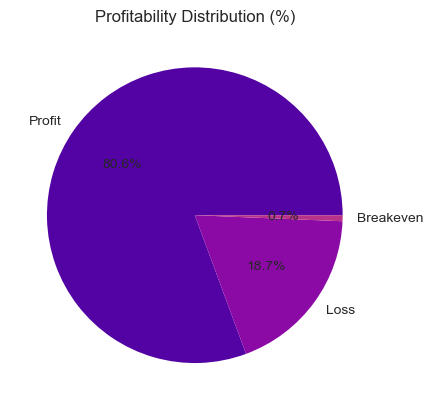

In [14]:
# Visualization of profitability distribution
profit_counts = df['ProfitStatus'].value_counts(normalize=True) * 100
profit_counts.plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.title('Profitability Distribution (%)')
plt.show()

#### Business KPI

In [15]:
def format_func(value):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'

# Filtering delayed orders
delayed_df = df[df['Delay'] > 0]

# Calculating key metrics
metrics = {}
metrics['Total Orders'] = len(df)
metrics['Late Deliveries'] = len(delayed_df)
metrics['90% Delay (days)'] = delayed_df['Delay'].quantile(0.90)
metrics['On time Delivery %'] = (1 - float(metrics['Late Deliveries']) / metrics['Total Orders']) * 100
metrics['Late Delivery %'] = float(metrics['Late Deliveries']) / metrics['Total Orders'] * 100
metrics['Total Profit'] = format_func(df.loc[df['Order Profit Per Order'] > 0, 'Order Profit Per Order'].sum())
metrics['Total Loss due to delays'] = format_func(df.loc[df['Delay'] > 0, 'Order Profit Per Order'].sum())

# Printing KPIs
print('\n--- Business KPIs ---\n')
for k, v in metrics.items():
    if isinstance(v, (int, float)):
        print(f'{k}: {v}')


--- Business KPIs ---

Total Orders: 180519
Late Deliveries: 98743
90% Delay (days): 3.0
On time Delivery %: 45.30049468477002
Late Delivery %: 54.69950531522998


In [16]:
# Calculating profitability vs delivery time analysis
profit_metrics = (
    df.groupby('Delay')['Order Profit Per Order']
    .agg(
        avg_profit='mean',
        total_profit='sum',
        order_count='count'
    )
    .reset_index()
)

profit_metrics 

,Delay,avg_profit,total_profit,order_count
0,-2,23.423528,5.074942e+05,21666
1,-1,21.516997,4.669188e+05,21700
2,0,22.044854,8.467429e+05,38410
3,1,22.225592,1.244411e+06,55990
4,2,21.246239,6.101495e+05,28718
5,3,19.941130,1.406248e+05,7052
6,4,21.561202,1.505619e+05,6983


In [17]:
# Calculating delay distribution
delay_distribution = (
    df['Delay']
    .value_counts(normalize=True)
    .sort_index() * 100
).reset_index()

delay_distribution

,Delay,proportion
0,-2,12.002061
1,-1,12.020895
2,0,21.277539
3,1,31.016126
4,2,15.908575
5,3,3.906514
6,4,3.868291



Profit Metrics by Delay Day:


,Delay,avg_profit,total_profit,order_count
0,-2,23.4,507494.2,21666
1,-1,21.5,466918.8,21700
2,0,22.0,846742.9,38410
3,1,22.2,1244410.9,55990
4,2,21.2,610149.5,28718
5,3,19.9,140624.8,7052
6,4,21.6,150561.9,6983



Delay Distribution (%):


,Delay Days,Percentage
0,-2,12.002061
1,-1,12.020895
2,0,21.277539
3,1,31.016126
4,2,15.908575
5,3,3.906514
6,4,3.868291


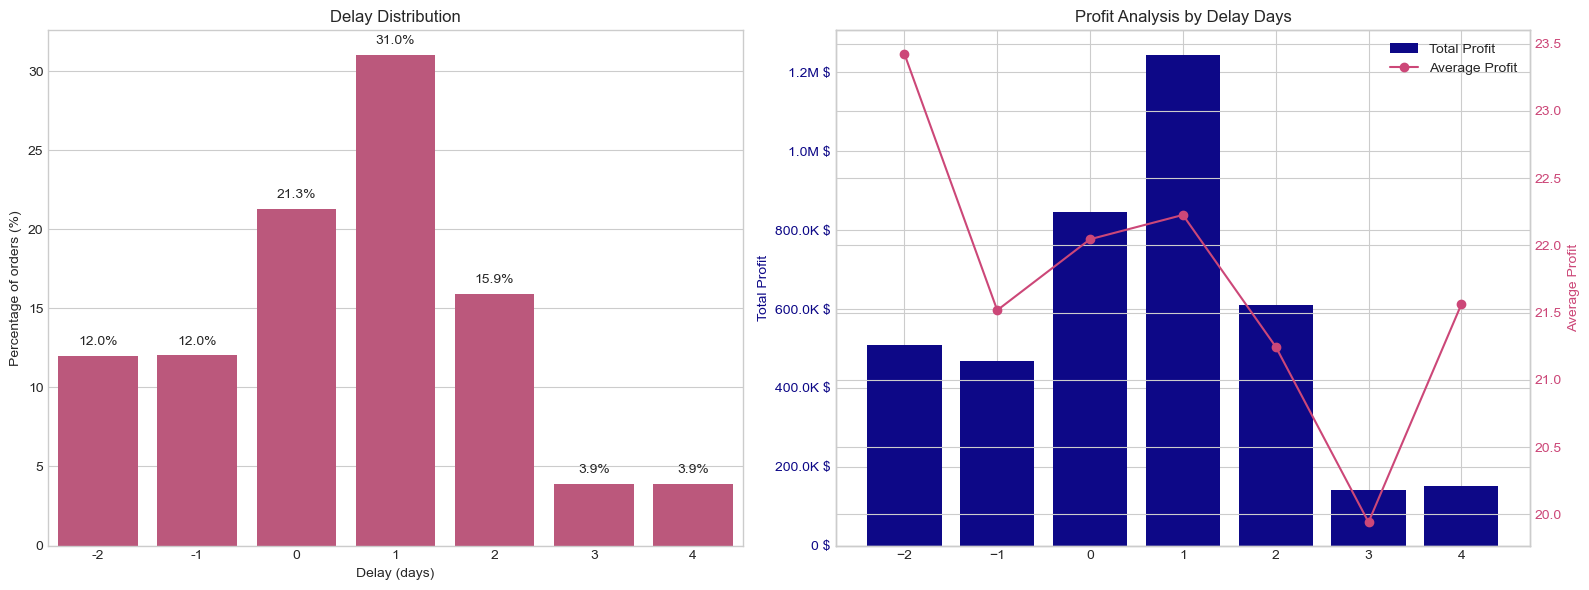

In [18]:
# Displaying delay distribution and profit metrics
delay_distribution.columns = ['Delay Days', 'Percentage']
print("\nProfit Metrics by Delay Day:")
display(profit_metrics.round(1))
print("\nDelay Distribution (%):")
display(delay_distribution)

# ✅ Define format_func FIRST before using it
def format_func(value, tick_number):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'

# Creating subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# First subplot: Delay Distribution
sns.barplot(x='Delay Days', y='Percentage', data=delay_distribution, color=accent_color, ax=ax1)
ax1.set_title('Delay Distribution')
ax1.set_xlabel('Delay (days)')
ax1.set_ylabel('Percentage of orders (%)')

# Adding percentage text on bars
for bar in ax1.patches:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height + 0.5, f'{height:.1f}%', ha='center', va='bottom')

# Second subplot: Profit Analysis by Delay Days
ax2.set_title("Profit Analysis by Delay Days")
ax2.set_ylabel("Total Profit", color=primary_color)
ax2.bar(profit_metrics['Delay'], profit_metrics['total_profit'], color=primary_color, label="Total Profit")
ax2.tick_params(axis='y', labelcolor=primary_color)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(format_func))

# Twin axis: Mean Profit line
ax3 = ax2.twinx()
ax3.set_ylabel("Average Profit", color=accent_color)
ax3.plot(profit_metrics['Delay'], profit_metrics['avg_profit'], marker='o', label='Average Profit', color=accent_color)
ax3.tick_params(axis='y', labelcolor=accent_color)

# Combined legend from both axes
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax3.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

#### Bottleneck detection

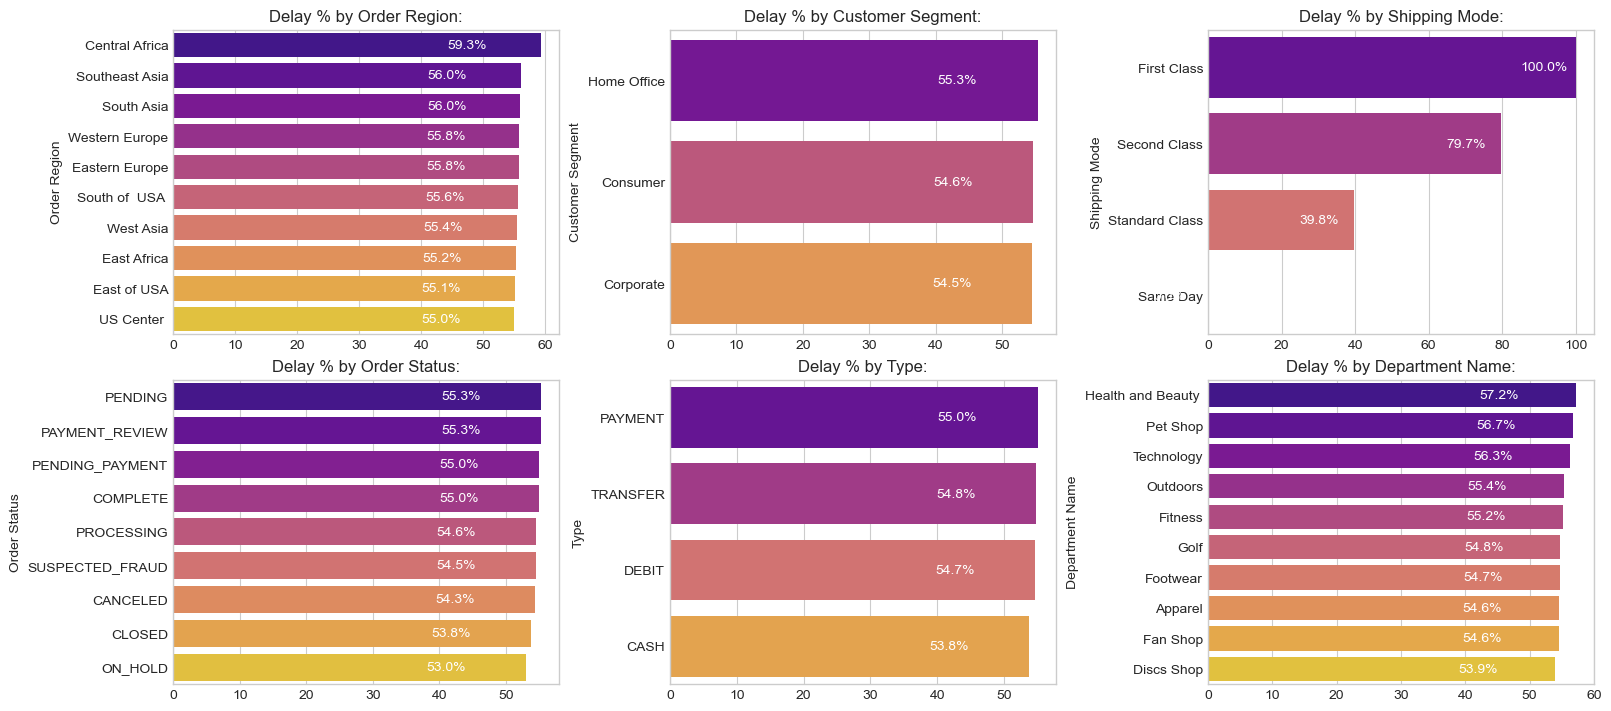

In [19]:
# Bottleneck Detection

def compute_delay_pct_by_category(category):
    cat_df = df.groupby(category).agg(
        total_orders=('Delay', 'count'),
        late_orders=('Is_Delayed', 'sum')
    )
    cat_df['delay_pct'] = cat_df['late_orders'] / cat_df['total_orders'] * 100
    cat_df = cat_df.sort_values('delay_pct', ascending=False).head(10)
    return cat_df
    
categories = ['Order Region', 'Customer Segment', 'Shipping Mode', 'Order Status', 'Type', 'Department Name']

fig, axes = plt.subplots(2, 3, figsize=(16, 7), constrained_layout=True)
axes = axes.flatten()

for ax, category in zip(axes, categories):
    cat_df = compute_delay_pct_by_category(category)
    sns.barplot(
        data=cat_df,
        x='delay_pct',
        y=category,
        ax=ax,
        palette='plasma'
    )
    ax.set_title(f'Delay % by {category}:')
    ax.set_xlabel('')
    ax.set_ylabel(category)
    for i, row in cat_df.reset_index().iterrows():
        ax.text(row['delay_pct'] - 15, i, f"{row['delay_pct']:.1f}%", va='center', fontsize=10, color='white')

plt.show()

In [20]:
def compute_delay_pct_by_category(category):
    cat_df = df.groupby(category).agg(
        total_orders=('Delay', 'count'),
        late_orders=('Is_Delayed', 'sum')
    ).reset_index()
    cat_df['delay_pct'] = cat_df['late_orders'] / cat_df['total_orders'] * 100
    cat_df = cat_df.sort_values('delay_pct', ascending=False).head(10)
    return cat_df

compute_delay_pct_by_category('Customer Segment')

,Customer Segment,total_orders,late_orders,delay_pct
2,Home Office,32226,17821,55.300068
0,Consumer,93504,51071,54.619054
1,Corporate,54789,29851,54.483564


#### Root Cause Analysis

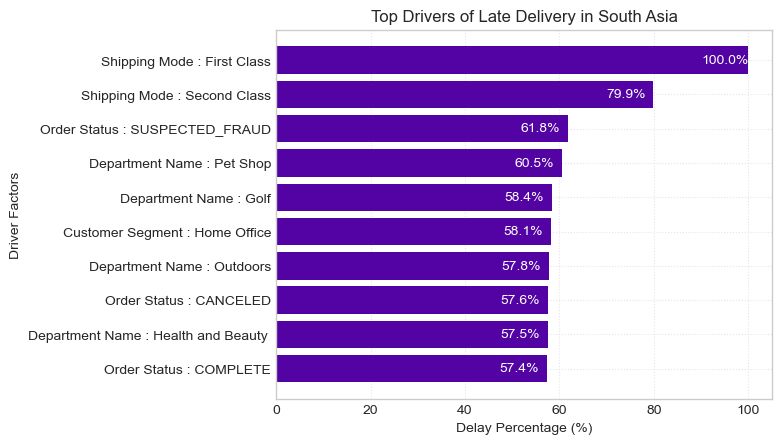

In [21]:
def top_drivers_for_regions(region):
    df_region = df[df['Order Region'] == region].copy()
    
    drivers = ['Shipping Mode', 'Customer Segment', 'Department Name', 'Type', 'Order Status']
    
    all_factors = []
    for factor in drivers:
        temp = (
            df_region.groupby(factor)
            .agg(
                total_orders=('Delay', 'count'),
                late_orders=('Is_Delayed', 'sum'),
                avg_delay=('Delay', 'mean')
            ).reset_index()
        )
        temp['delay_pct'] = temp['late_orders'] / temp['total_orders'] * 100
        temp['Driver'] = factor
        temp['Factor_Level'] = factor + " : " + temp[factor].astype(str)
        all_factors.append(temp[['Driver', 'Factor_Level', 'delay_pct', 'avg_delay', 'total_orders']])

    # Combine all drivers
    final_df = pd.concat(all_factors)

    # Sorting by delay percentage
    top_factors = final_df.sort_values('delay_pct', ascending=False).head(10)

    plt.figure()
    bars = plt.barh(top_factors['Factor_Level'], top_factors['delay_pct'])
    plt.xlabel("Delay Percentage (%)")
    plt.ylabel("Driver Factors")
    plt.title(f"Top Drivers of Late Delivery in {region}") 
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.gca().invert_yaxis()
    for bar in bars:
        width = bar.get_width()
        plt.text(width - 10, bar.get_y() + bar.get_height() / 2, f"{width:.1f}%", va='center', fontsize=10, color='white')
    plt.show()

top_drivers_for_regions('South Asia') 

### Time based analysis

In [22]:
# Delay % by Month, Day of Week, Hour

delay_by_month = (
    df.groupby('order_month')['Is_Delayed']
    .mean()
    .reset_index()
)
delay_by_month['delay_pct'] = delay_by_month['Is_Delayed'] * 100

delay_by_day = (
    df.groupby('order_day')['Is_Delayed']
    .mean()
    .reset_index()
)
delay_by_day['delay_pct'] = delay_by_day['Is_Delayed'] * 100

delay_by_hour = (
    df.groupby('order_hour')['Is_Delayed']
    .mean()
    .reset_index()
)
delay_by_hour['delay_pct'] = delay_by_hour['Is_Delayed'] * 100

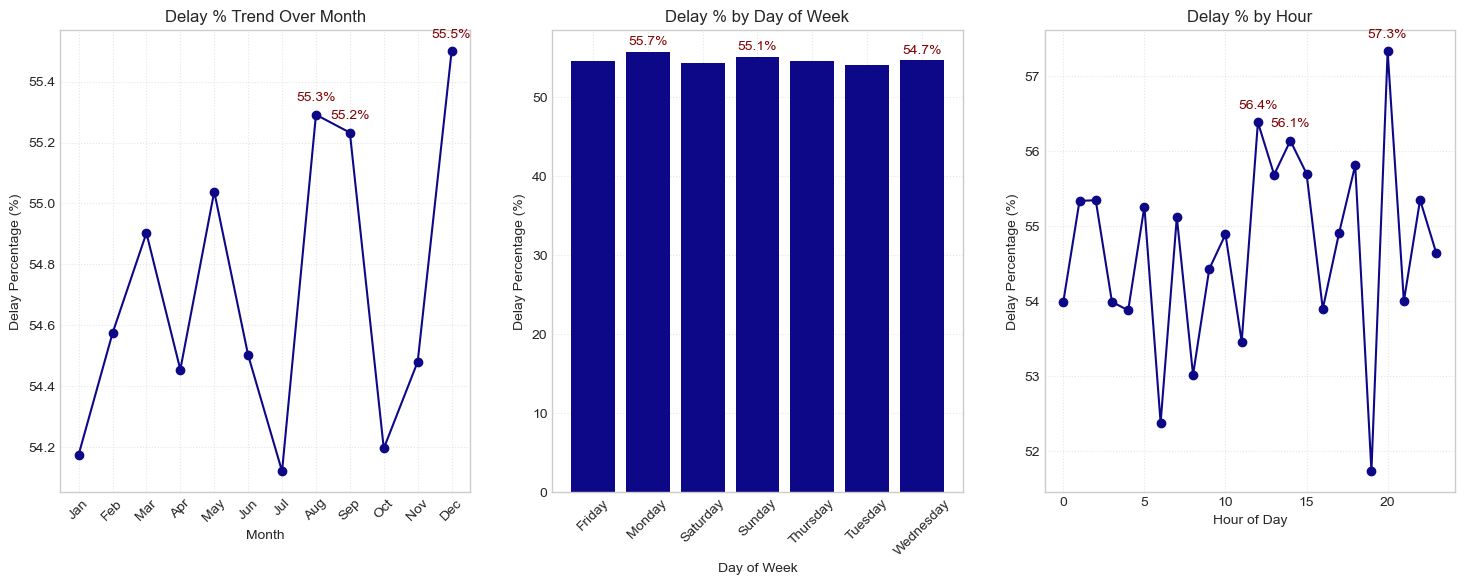

In [23]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Subplot 1: Delay % Trend Over Month
ax1.plot(delay_by_month['order_month'], delay_by_month['delay_pct'], marker='o', color=primary_color)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
ax1.set_xlabel("Month")
ax1.set_ylabel("Delay Percentage (%)")
ax1.set_title("Delay % Trend Over Month")
ax1.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest
top3_month = delay_by_month.nlargest(3, 'delay_pct')
for _, row in top3_month.iterrows():
    ax1.annotate(f"{row['delay_pct']:.1f}%", (row['order_month'], row['delay_pct']),
                 textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10, color=danger_color)

# Subplot 2: Delay % by Day of Week
ax2.bar(delay_by_day['order_day'], delay_by_day['delay_pct'], color=primary_color)
ax2.set_xticklabels(delay_by_day['order_day'], rotation=45)
ax2.set_xlabel('Day of Week')
ax2.set_ylabel('Delay Percentage (%)')
ax2.set_title("Delay % by Day of Week")
ax2.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest bars
top3_day = delay_by_day.nlargest(3, 'delay_pct')
for _, row in top3_day.iterrows():
    height = row['delay_pct']
    ax2.text(row['order_day'], height + 0.5, f'{height:.1f}%', ha='center', va='bottom', fontsize=10, color=danger_color)

# Subplot 3: Delay % by Hour
ax3.plot(delay_by_hour['order_hour'], delay_by_hour['delay_pct'], marker='o', color=primary_color)
ax3.set_xlabel('Hour of Day')
ax3.set_ylabel('Delay Percentage (%)')
ax3.set_title("Delay % by Hour")
ax3.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest
top3_hour = delay_by_hour.nlargest(3, 'delay_pct')
for _, row in top3_hour.iterrows():
    ax3.annotate(f"{row['delay_pct']:.1f}%", (row['order_hour'], row['delay_pct']),
                 textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10, color=danger_color)

plt.show()